# GeologyManager class
This notebook display how the GeologyManager() class works with a 2D case.

In [1]:
import pykasso as pk
import numpy   as np
import matplotlib.pyplot as plt

In [2]:
# First create grid object
x0, y0, z0 = 0, 0, 0
nx, ny, nz = 10, 10, 1
dx, dy, dz = 10, 10, 10

grid = pk.Grid(x0,y0,z0,nx,ny,nz,dx,dy,dz)

In [3]:
# Set a seed (for reproducibility)
seed = 1
np.random.seed(seed)

In [4]:
# Then create geology manager
geology = pk.GeologyManager(grid)

## Add data

**set_data_null():**

**set_data_from_csv():**
- [???] Only usable for 2D cases (e.g. nz=1) ;
- Delimiter is comma (e.g. ',') ;
- [???] nx = number of rows && ny = number of columns ;

**set_data_from_gslib():**
- If value==0, it will replaced by nan ;
- Only one column of data is accepted ;

**set_data_from_image():**
- Only available for 2D cases (e.g nz=1) ;
- [???] Accepted formats : .???, .??? ;
- Work only with binary image (e.g. black&white image);
- It should be used only for quick testing ;
- [???] geology   : white = 0 = aquifer / black = 1 = aquitard
- [???] faults    : white = 0 = no faults / black = 1 = faults
- [???] fractures : white = 0 = no fractures / black = 1 = fractures

### Geology, Faults and Fractures

set_data_from_csv() : geology


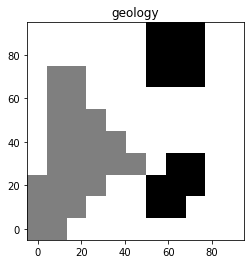

set_data_from_gslib() : geology


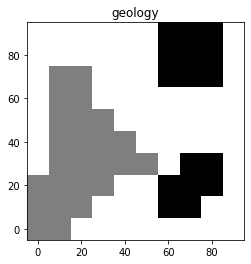

set_data_from_image() : geology


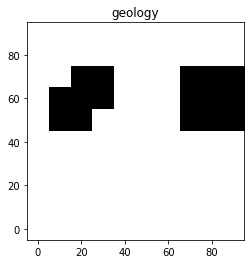

set_data_from_csv() : faults


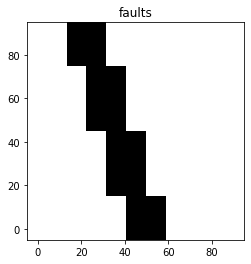

set_data_from_gslib() : faults


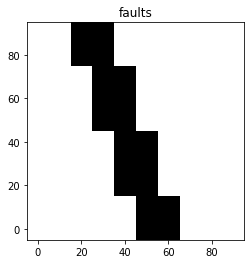

set_data_from_image() : faults


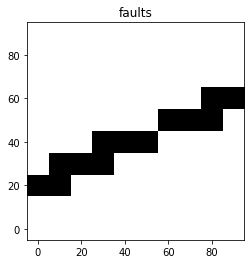

In [5]:
#### CHANGER LA VIZU

data_labels = ["geology", "faults"]#, "fractures"]

for data_label in data_labels:
    # set_data_from_csv()
    print("set_data_from_csv() : {}".format(data_label))
    geology.set_data_from_csv(data_label, "inputs/{}_2D.csv".format(data_label))
    geology.show(data=data_label)

    # set_data_from_gslib()
    print("set_data_from_gslib() : {}".format(data_label))
    geology.set_data_from_gslib(data_label, "inputs/{}_2D.gslib".format(data_label))
    geology.show(data=data_label)

    # set_data_from_image() is available only when nz=1. 
    print("set_data_from_image() : {}".format(data_label))
    geology.set_data_from_image(data_label, "inputs/{}_2D.png".format(data_label))
    geology.show(data=data_label)

### Topography and Orientation

In [6]:
# Set "geology", "topography", "orientation", "faults" and "fractures" data
geology.set_data_null("geology")
geology.set_data_null("topography")
geology.set_data_null("orientation")
geology.set_data_null("faults")
geology.set_data_null("fractures")

In [7]:
# Fracture generation settings
fractures_densities = [0.00005]
fractures_alpha = [2]
fractures_min_orientation = [0]
fractures_max_orientation = [150]
fractures_min_dip = [89]
fractures_max_dip = [90]
fractures_min_length = [200]
fractures_max_length = [1000]

In [8]:
# Generate fractures
geology.generate_fractures(fractures_densities, fractures_alpha, 
                           fractures_min_orientation, fractures_max_orientation,
                           fractures_min_dip,fractures_max_dip,
                           fractures_min_length, fractures_max_length)

In [9]:
# Rasterize fractures
frac = geology.rasterize_fracture_network()

Rasterizing: 100%|█████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 1998.24it/s]


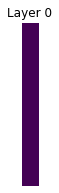

In [10]:
import matplotlib.pyplot as plt
for k in range(grid.nz):    
    plt.figure( figsize=(3,3) )
    plt.imshow(frac[k,:,:], origin='lower')
    plt.title('Layer '+str(k))
    plt.axis('off')
    plt.show()

In [11]:
# Fractures are stored in this list
geology.fractures

[[id:0, fam.:0, x:5.47, y:-25.65, z:-8.15, rad:117.51, or.:1.65, dip.:0.0, n:(-1.0,0.08,-0.0)] ,
 [id:1, fam.:0, x:28.84, y:82.04, z:-5.91, rad:336.13, or.:1.28, dip.:0.0, n:(-0.96,-0.28,-0.0)] ]

In [12]:
# Visualize fractures with pyvista

import pyvista as pv
frac = geology.fractures

p = pv.Plotter()
for f in frac:
    x, y, z = f.get_position()
    a, b, c = f.get_normal()
    print(f.get_normal())
    pol = pv.Polygon(center=(x, y, z), radius=f.radius, normal=(a, b, c), n_sides=12)
    p.add_mesh(pol, color="tan", show_edges=True)
p.show_bounds()

p.show()

ModuleNotFoundError: No module named 'pyvista'